Importing the necessary Libraries

In [2]:
import pandas as pd
import numpy as np
from utils.funcs import get_variable_names, rename_columns, processed_diabetes_data, demographic_data2
from functools import reduce
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import StackingClassifier,RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, AdaBoostClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE
import optuna
import lightgbm as lgb
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE,RandomOverSampler
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, make_scorer
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split, GridSearchCV
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer, KNNImputer
import xgboost as xgb
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

c:\Users\bipan\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Reading different dataset 

In [4]:
def read_file(filename=''):

    dataset_path='raw_datasets'
    df=pd.read_sas(f'{dataset_path}/{filename}.XPT', format='xport')
    mapping=get_variable_names()
    df=rename_columns(df, mapping)  
    threshold = int(0.7 * len(df))  
    df = df.dropna(axis=1, thresh=threshold)
    return df

In [5]:
df_diabetes=processed_diabetes_data()  
df_demographic=demographic_data2()
df_audio=read_file('audiometry')
df_blood_pressure=read_file('blood_pressure_cholesterol')
df_general_health=read_file('hospital_utilization_access_to_care')
df_weight=read_file('weight_history')
df_occupation=read_file('occupation')
df_sleep=read_file('sleep_disorders')
df_smoke1=read_file('smoking_cigarette_use')
df_phy_activity=read_file('physical_activity')
df_alcohol=read_file('alcohol_use')

### Merging different datasets

In [6]:
dataframes = [df_diabetes,df_demographic, df_audio, df_blood_pressure, df_general_health, df_weight, df_occupation,df_sleep,df_smoke1,df_phy_activity,df_alcohol]
df = reduce(lambda left, right: pd.merge(left, right, on='sequence_no', how='inner'), dataframes)

In [7]:
columns_to_select = ['sequence_no', 'EverTold_Diabetes', 'race', 'gender', 'age','sample_weight','sample_weight2','HearingStatus_NoAid','EverTold_Hypertension','EverTold_HighCholesterol','CurrentlyTaking_CholesterolMedication','GeneralHealth_Status','CurrentHeight','CurrentWeight','WorkExperience_LastWeek','WeightOneYearAgo','SmokedAtLeast100CigarettesInLife','EverHad_Alcohol','SittingTime_TypicalDay','WeekdaySleepHours','AlcoholConsumptionFrequency_12Months','Duration_ModerateActivity_PerSession','Frequency_ModerateActivity']
df=df[columns_to_select]


### Replace the 'don't know' and 'refused' values

In [8]:
df['EverHad_Alcohol'] = df['EverHad_Alcohol'].replace(7.0, 1.0)
df['AlcoholConsumptionFrequency_12Months'] = df['AlcoholConsumptionFrequency_12Months'].replace(77.0, 1.0)
df['AlcoholConsumptionFrequency_12Months'] = df['AlcoholConsumptionFrequency_12Months'].replace(99.0, 1.0)
df['EverTold_Hypertension'] = df['EverTold_Hypertension'].replace(9.0, 2.0)
df['EverTold_HighCholesterol'] = df['EverTold_HighCholesterol'].replace(9.0, 2.0)
df['CurrentlyTaking_CholesterolMedication'] = df['CurrentlyTaking_CholesterolMedication'].replace(9.0, 2.0)
df['GeneralHealth_Status'] = df['GeneralHealth_Status'].replace(9.0, 4.0)
df['Frequency_ModerateActivity'] = df['Frequency_ModerateActivity'].replace(9999.0, np.nan)
df['Frequency_ModerateActivity'] = df['Frequency_ModerateActivity'].replace(7777.0, np.nan)
df['Duration_ModerateActivity_PerSession'] = df['Duration_ModerateActivity_PerSession'].replace(7777.0, np.nan)
df['SmokedAtLeast100CigarettesInLife'] = df['SmokedAtLeast100CigarettesInLife'].replace(9.0, np.nan)
df['SmokedAtLeast100CigarettesInLife'] = df['SmokedAtLeast100CigarettesInLife'].replace(7.0, np.nan)
df['CurrentHeight'] = df['CurrentHeight'].replace(7777.0, np.nan)
df['CurrentHeight'] = df['CurrentHeight'].replace(9999.0, np.nan)
df['CurrentWeight'] = df['CurrentWeight'].replace(9999.0, np.nan)
df['CurrentWeight'] = df['CurrentWeight'].replace(7777.0, np.nan)
df['WeightOneYearAgo'] = df['WeightOneYearAgo'].replace(7777.0, np.nan)
df['WeightOneYearAgo'] = df['WeightOneYearAgo'].replace(9999.0, np.nan)
df['SittingTime_TypicalDay'] = df['SittingTime_TypicalDay'].replace(9999.0, np.nan)
df['SittingTime_TypicalDay'] = df['SittingTime_TypicalDay'].replace(7777.0, np.nan)
df['WorkExperience_LastWeek'] = df['WorkExperience_LastWeek'].replace(9.0, np.nan)




In [9]:
nan_counts = df.isnull().sum()
nan_counts

sequence_no                                 0
EverTold_Diabetes                           0
race                                        0
gender                                      0
age                                         0
sample_weight                               0
sample_weight2                              0
HearingStatus_NoAid                         0
EverTold_Hypertension                       0
EverTold_HighCholesterol                    0
CurrentlyTaking_CholesterolMedication       0
GeneralHealth_Status                        0
CurrentHeight                              49
CurrentWeight                              79
WorkExperience_LastWeek                     1
WeightOneYearAgo                          114
SmokedAtLeast100CigarettesInLife            9
EverHad_Alcohol                           812
SittingTime_TypicalDay                     45
WeekdaySleepHours                          61
AlcoholConsumptionFrequency_12Months     1357
Duration_ModerateActivity_PerSessi

### Imputing continuous variables with iterative imputer

In [10]:

temp_df=df[['CurrentHeight','CurrentWeight','WeightOneYearAgo','Duration_ModerateActivity_PerSession','Frequency_ModerateActivity','age','SittingTime_TypicalDay','WeekdaySleepHours']]
imputer = IterativeImputer(random_state=0)
imputed_data = imputer.fit_transform(temp_df)
imputed_df = pd.DataFrame(imputed_data, columns=temp_df.columns)
df[['CurrentHeight','CurrentWeight','WeightOneYearAgo','Duration_ModerateActivity_PerSession','Frequency_ModerateActivity','age','SittingTime_TypicalDay','WeekdaySleepHours']]=imputed_df


### Imputing categorical variables with knn imputer

In [11]:
imputer = KNNImputer(n_neighbors=1)
imputed_data = imputer.fit_transform(df)
df = pd.DataFrame(imputed_data, columns=df.columns)

In [12]:
df.isnull().sum()

sequence_no                              0
EverTold_Diabetes                        0
race                                     0
gender                                   0
age                                      0
sample_weight                            0
sample_weight2                           0
HearingStatus_NoAid                      0
EverTold_Hypertension                    0
EverTold_HighCholesterol                 0
CurrentlyTaking_CholesterolMedication    0
GeneralHealth_Status                     0
CurrentHeight                            0
CurrentWeight                            0
WorkExperience_LastWeek                  0
WeightOneYearAgo                         0
SmokedAtLeast100CigarettesInLife         0
EverHad_Alcohol                          0
SittingTime_TypicalDay                   0
WeekdaySleepHours                        0
AlcoholConsumptionFrequency_12Months     0
Duration_ModerateActivity_PerSession     0
Frequency_ModerateActivity               0
dtype: int6

### Create new Features

In [13]:
df['bmi']=(df['CurrentWeight']/(df['CurrentHeight']**2))*703
df['weight_diff']=df['CurrentWeight']-df['WeightOneYearAgo']
df['activity_time']=df['Duration_ModerateActivity_PerSession']*df['Frequency_ModerateActivity']

In [13]:
df.columns

Index(['sequence_no', 'EverTold_Diabetes', 'race', 'gender', 'age',
       'sample_weight', 'sample_weight2', 'HearingStatus_NoAid',
       'EverTold_Hypertension', 'EverTold_HighCholesterol',
       'CurrentlyTaking_CholesterolMedication', 'GeneralHealth_Status',
       'CurrentHeight', 'CurrentWeight', 'WorkExperience_LastWeek',
       'WeightOneYearAgo', 'SmokedAtLeast100CigarettesInLife',
       'EverHad_Alcohol', 'SittingTime_TypicalDay', 'WeekdaySleepHours',
       'AlcoholConsumptionFrequency_12Months',
       'Duration_ModerateActivity_PerSession', 'Frequency_ModerateActivity',
       'bmi', 'weight_diff', 'activity_time'],
      dtype='object')

In [14]:
num_col=['age','sample_weight','sample_weight2','CurrentHeight','CurrentWeight','WeightOneYearAgo','SittingTime_TypicalDay','WeekdaySleepHours','AlcoholConsumptionFrequency_12Months','Duration_ModerateActivity_PerSession','Frequency_ModerateActivity','bmi','weight_diff','activity_time']

In [15]:
df['EverTold_Diabetes']=df['EverTold_Diabetes'].astype(int)

### Converting categorical variables to one hot encoded features

In [16]:
category_cols=['race','GeneralHealth_Status','WorkExperience_LastWeek','SmokedAtLeast100CigarettesInLife']
df1 = pd.get_dummies(df, columns=category_cols)

### t-SNE Plots 

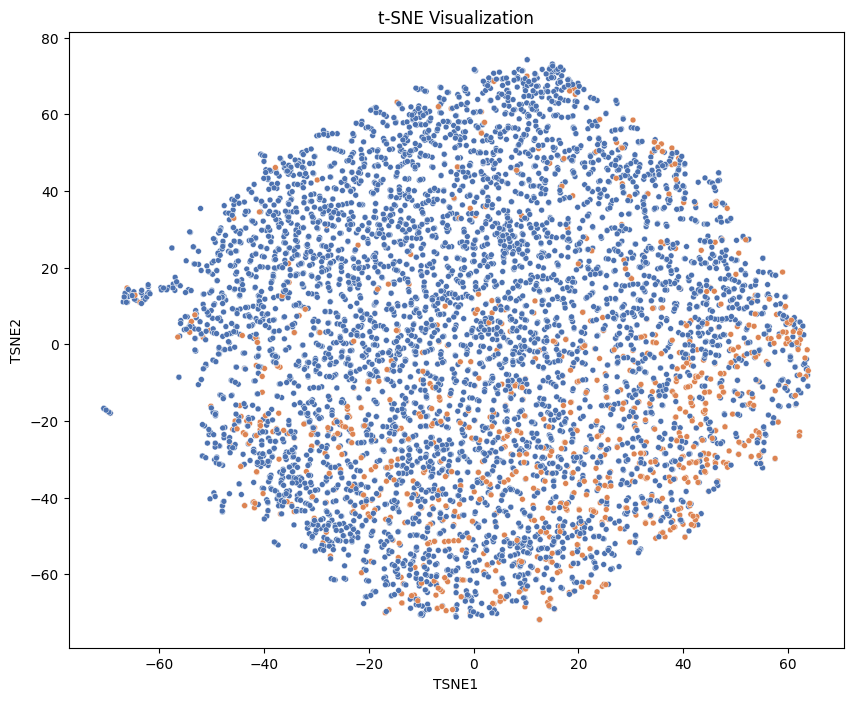

<Figure size 640x480 with 0 Axes>

In [ ]:
X = df1.drop(['EverTold_Diabetes','sequence_no'], axis=1) 
y = df1['EverTold_Diabetes'] 

scaler = StandardScaler()
X[num_col] = scaler.fit_transform(X[num_col])

pca = PCA(n_components=15, random_state=42)
pca_features = pca.fit_transform(X)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(pca_features)

df_tsne = pd.DataFrame(data=tsne_results, columns=['TSNE1', 'TSNE2'])


df_tsne['target'] = y.reset_index(drop=True)  

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', hue='target', palette='deep', size=1, legend=False)
plt.title('t-SNE Visualization')
plt.show()
plt.clf()


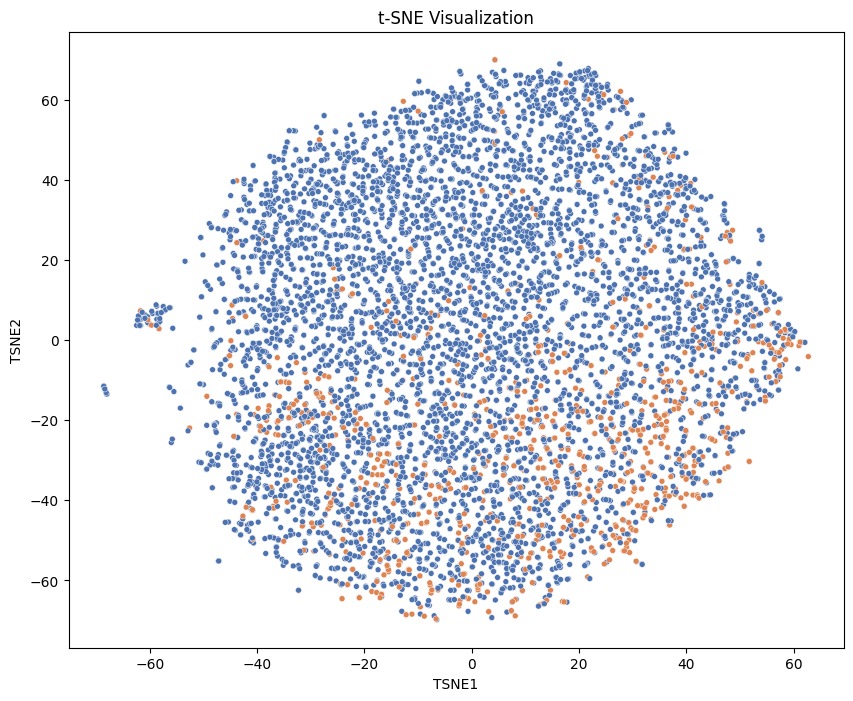

<Figure size 640x480 with 0 Axes>

In [51]:
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(X)

df_tsne = pd.DataFrame(data=tsne_results, columns=['TSNE1', 'TSNE2'])

df_tsne['target'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', hue='target', palette='deep', size=1, legend=False)

plt.title('t-SNE Visualization')
plt.show()
plt.clf()


### Correlation Matrices

In [54]:
corr_matrix = df.drop('sequence_no', axis=1).corr()
corr_matrix

,EverTold_Diabetes,race,gender,age,sample_weight,sample_weight2,HearingStatus_NoAid,EverTold_Hypertension,EverTold_HighCholesterol,CurrentlyTaking_CholesterolMedication,...,SmokedAtLeast100CigarettesInLife,EverHad_Alcohol,SittingTime_TypicalDay,WeekdaySleepHours,AlcoholConsumptionFrequency_12Months,Duration_ModerateActivity_PerSession,Frequency_ModerateActivity,bmi,weight_diff,activity_time
EverTold_Diabetes,1.000000,0.024139,-0.032315,0.249180,-0.098781,-0.100915,0.152948,-0.307274,-0.277625,-0.370333,...,-0.092132,0.043813,0.047186,0.013603,-0.005645,0.031678,-0.074550,0.196578,-0.130136,-0.005523
race,0.024139,1.000000,-0.007946,0.006562,-0.013050,-0.006758,-0.034238,-0.027499,-0.003064,-0.013144,...,-0.040325,0.010347,0.047631,-0.032506,-0.017495,0.021019,0.016951,-0.053462,0.001718,-0.006896
gender,-0.032315,-0.007946,1.000000,-0.004235,-0.103613,-0.095628,-0.096028,0.021255,0.016926,0.062009,...,0.115398,0.027553,-0.021843,0.042350,0.094367,-0.020416,-0.024141,0.049474,-0.008427,-0.025968
age,0.249180,0.006562,-0.004235,1.000000,-0.333023,-0.344980,0.324811,-0.418738,-0.414624,-0.464367,...,-0.203880,-0.009361,-0.047564,0.013210,-0.165290,0.021593,-0.045544,0.016037,-0.089776,0.002435
sample_weight,-0.098781,-0.013050,-0.103613,-0.333023,1.000000,0.952841,-0.091291,0.174403,0.132072,0.162037,...,0.085983,-0.057648,0.031529,-0.011849,0.068376,-0.011102,0.014677,0.002417,0.047692,0.000389
sample_weight2,-0.100915,-0.006758,-0.095628,-0.344980,0.952841,1.000000,-0.087770,0.181232,0.150574,0.172858,...,0.084862,-0.033605,0.011743,0.001189,0.066052,-0.009577,0.012866,-0.006681,0.053109,0.003811
HearingStatus_NoAid,0.152948,-0.034238,-0.096028,0.324811,-0.091291,-0.087770,1.000000,-0.180310,-0.177497,-0.208117,...,-0.138669,0.000131,0.023903,0.024166,-0.049931,0.035645,-0.036023,0.047545,-0.024772,0.025532
EverTold_Hypertension,-0.307274,-0.027499,0.021255,-0.418738,0.174403,0.181232,-0.180310,1.000000,0.348335,0.396511,...,0.133908,-0.018072,-0.036836,0.000476,0.074176,-0.016886,0.042783,-0.205131,0.085050,-0.001876
EverTold_HighCholesterol,-0.277625,-0.003064,0.016926,-0.414624,0.132072,0.150574,-0.177497,0.348335,1.000000,0.613602,...,0.117874,0.012693,-0.042408,-0.000453,0.067826,-0.024154,0.022212,-0.111030,0.072931,-0.020701
CurrentlyTaking_CholesterolMedication,-0.370333,-0.013144,0.062009,-0.464367,0.162037,0.172858,-0.208117,0.396511,0.613602,1.000000,...,0.121204,-0.017401,-0.003642,-0.035750,0.073725,-0.025727,0.046671,-0.105108,0.080036,-0.015628


In [55]:
corr_matrix_encoded = df1.drop('sequence_no', axis=1).corr()
corr_matrix_encoded

,EverTold_Diabetes,gender,age,sample_weight,sample_weight2,HearingStatus_NoAid,EverTold_Hypertension,EverTold_HighCholesterol,CurrentlyTaking_CholesterolMedication,CurrentHeight,...,GeneralHealth_Status_2.0,GeneralHealth_Status_3.0,GeneralHealth_Status_4.0,GeneralHealth_Status_5.0,WorkExperience_LastWeek_1.0,WorkExperience_LastWeek_2.0,WorkExperience_LastWeek_3.0,WorkExperience_LastWeek_4.0,SmokedAtLeast100CigarettesInLife_1.0,SmokedAtLeast100CigarettesInLife_2.0
EverTold_Diabetes,1.000000,-0.032315,0.249180,-0.098781,-0.100915,0.152948,-0.307274,-0.277625,-0.370333,-0.020752,...,-0.153633,0.050780,0.193639,0.151117,-0.174404,-0.024594,-0.023233,0.195335,0.092132,-0.092132
gender,-0.032315,1.000000,-0.004235,-0.103613,-0.095628,-0.096028,0.021255,0.016926,0.062009,-0.677541,...,0.005954,0.009310,0.019489,-0.005788,-0.062175,0.030733,-0.004222,0.053756,-0.115398,0.115398
age,0.249180,-0.004235,1.000000,-0.333023,-0.344980,0.324811,-0.418738,-0.414624,-0.464367,-0.063555,...,-0.054187,0.045426,0.083200,0.066930,-0.386071,-0.050088,-0.154788,0.472580,0.203880,-0.203880
sample_weight,-0.098781,-0.103613,-0.333023,1.000000,0.952841,-0.091291,0.174403,0.132072,0.162037,0.116734,...,0.062614,-0.011172,-0.078729,-0.046296,0.212742,0.017884,0.012605,-0.227552,-0.085983,0.085983
sample_weight2,-0.100915,-0.095628,-0.344980,0.952841,1.000000,-0.087770,0.181232,0.150574,0.172858,0.097483,...,0.055804,-0.016865,-0.073381,-0.044988,0.194310,0.012548,0.019466,-0.209683,-0.084862,0.084862
HearingStatus_NoAid,0.152948,-0.096028,0.324811,-0.091291,-0.087770,1.000000,-0.180310,-0.177497,-0.208117,0.020910,...,-0.102851,0.054573,0.162611,0.108956,-0.175694,-0.034378,-0.051506,0.211592,0.138669,-0.138669
EverTold_Hypertension,-0.307274,0.021255,-0.418738,0.174403,0.181232,-0.180310,1.000000,0.348335,0.396511,0.039319,...,0.134921,-0.078535,-0.173454,-0.131064,0.229813,0.038894,0.055264,-0.269688,-0.133908,0.133908
EverTold_HighCholesterol,-0.277625,0.016926,-0.414624,0.132072,0.150574,-0.177497,0.348335,1.000000,0.613602,0.029881,...,0.049066,-0.041682,-0.105717,-0.073858,0.195856,0.017977,0.074504,-0.235440,-0.117874,0.117874
CurrentlyTaking_CholesterolMedication,-0.370333,0.062009,-0.464367,0.162037,0.172858,-0.208117,0.396511,0.613602,1.000000,0.012908,...,0.072160,-0.059517,-0.108437,-0.089295,0.263100,0.046343,0.052862,-0.305202,-0.121204,0.121204
CurrentHeight,-0.020752,-0.677541,-0.063555,0.116734,0.097483,0.020910,0.039319,0.029881,0.012908,1.000000,...,0.041616,-0.036761,-0.055729,-0.032472,0.105416,-0.001645,-0.003537,-0.105015,0.073364,-0.073364


In [17]:
X = df1.drop(['EverTold_Diabetes', 'sequence_no','CurrentHeight','CurrentWeight','WeightOneYearAgo','Duration_ModerateActivity_PerSession','Frequency_ModerateActivity'], axis=1) 
y = df1['EverTold_Diabetes']
X_np = X.to_numpy()
y_np = y.to_numpy()
num_col_reduced=['age','sample_weight','sample_weight2','SittingTime_TypicalDay','WeekdaySleepHours','AlcoholConsumptionFrequency_12Months','weight_diff','activity_time']
numeric_column_indices = [X.columns.get_loc(col) for col in num_col_reduced]

### Important Features using logistic regression

c:\Users\bipan\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


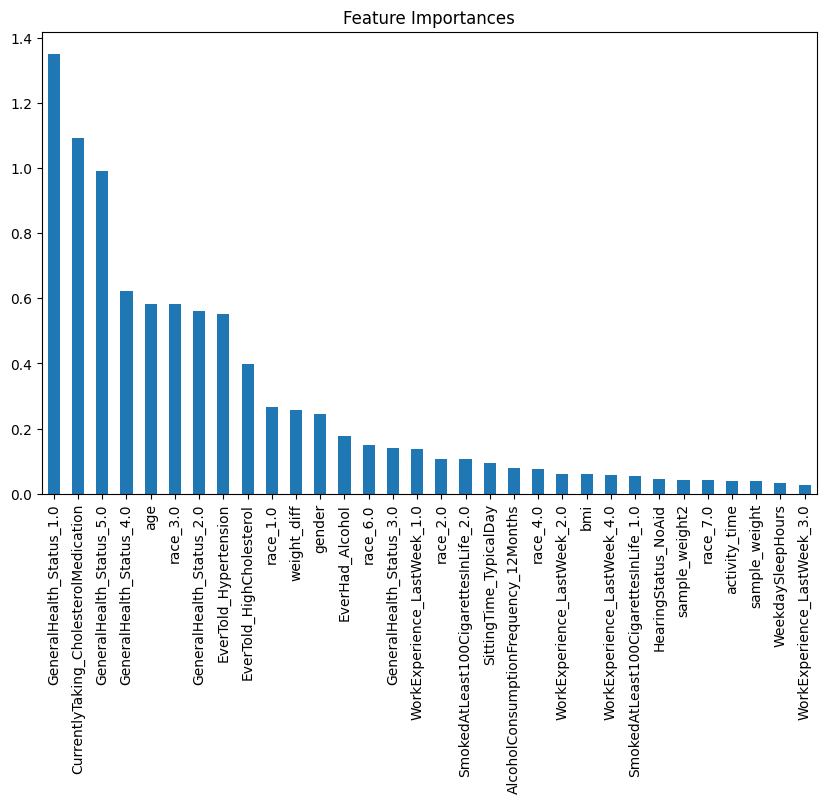

In [ ]:
x_copy=X
scaler = StandardScaler()
x_copy[num_col_reduced] = scaler.fit_transform(x_copy[num_col_reduced])
model = LogisticRegression(random_state=42)
model.fit(x_copy,y)

feature_importances = pd.Series(abs(model.coef_[0]), index=x_copy.columns)
feature_importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))
plt.title("Feature Importances")
plt.show()

In [ ]:
top_features = feature_importances.sort_values(ascending=False).head(15)

top_feature_names = top_features.index.tolist()

print("Top 15 Features:")
print(top_feature_names)

Top 15 Features:
['GeneralHealth_Status_1.0', 'CurrentlyTaking_CholesterolMedication', 'GeneralHealth_Status_5.0', 'GeneralHealth_Status_4.0', 'age', 'race_3.0', 'GeneralHealth_Status_2.0', 'EverTold_Hypertension', 'EverTold_HighCholesterol', 'race_1.0', 'weight_diff', 'gender', 'EverHad_Alcohol', 'race_6.0', 'GeneralHealth_Status_3.0']


### Logistic Regression hyperparameters optimization

In [ ]:
def tune_logistic_regression(X, y, numeric_features, sampler=None):
    preprocessor = ColumnTransformer(
        transformers=[('scaler', StandardScaler(), numeric_features)],
        remainder='passthrough'
    )

    logistic_reg = LogisticRegression(random_state=42, max_iter=500)

    if sampler:
        pipeline = ImbPipeline([
            ('preprocessor', preprocessor),
            ('sampler', sampler),
            ('classifier', logistic_reg)
        ])
    else:
        pipeline = make_pipeline(preprocessor, logistic_reg)

    param_grid = {
        'logisticregression__C': [0.01, 0.1, 1, 10, 100], 
        'logisticregression__penalty': ['l1', 'l2'],      
        'logisticregression__solver': ['liblinear', 'saga']  
    }

    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        scoring='roc_auc',
        cv=5,  
        verbose=1,
        n_jobs=-1
    )

    grid_search.fit(X, y)

    print("Best parameters found:", grid_search.best_params_)
    print("Best AUC-ROC score:", grid_search.best_score_)

    return grid_search.best_estimator_


best_model = tune_logistic_regression(X_np, y_np, numeric_column_indices)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters found: {'logisticregression__C': 0.1, 'logisticregression__penalty': 'l1', 'logisticregression__solver': 'liblinear'}
Best AUC-ROC score: 0.8625063778428135


In [ ]:
def evaluate_with_kfold_lr(X, y, numeric_features, sampler=None, n_splits=5, model=None):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    preprocessor = ColumnTransformer(
        transformers=[('scaler', StandardScaler(), numeric_features)],
        remainder='passthrough' 
    )

    auc_scores = []
    accuracy_scores = []

    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X[train_idx], X[valid_idx]
        y_train, y_valid = y[train_idx], y[valid_idx]

        X_train = preprocessor.fit_transform(X_train)
        X_valid = preprocessor.transform(X_valid)

        if sampler:
            X_train, y_train = sampler.fit_resample(X_train, y_train)

        model.fit(X_train, y_train)

        y_pred_proba = model.predict_proba(X_valid)
        y_pred = (y_pred_proba[:, 1] >= 0.5).astype(int)

        auc_roc = roc_auc_score(y_valid, y_pred_proba[:, 1])
        accuracy = accuracy_score(y_valid, y_pred)

        auc_scores.append(auc_roc)
        accuracy_scores.append(accuracy)

    avg_auc = np.mean(auc_scores)
    avg_accuracy = np.mean(accuracy_scores)
    
    return avg_auc, avg_accuracy

logistic_reg = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=500, class_weight='balanced')

# Evaluate original data
auc_original, acc_original = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices,model=logistic_reg)

# Evaluate with Tomek Links
tomek = TomekLinks()
auc_tomek, acc_tomek = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=tomek,model=logistic_reg)

# Evaluate with SMOTE + Tomek
smote_tomek = SMOTETomek(random_state=42)
auc_smote_tomek, acc_smote_tomek = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=smote_tomek,model=logistic_reg)

# Evaluate with Borderline-SMOTE
borderline_smote = BorderlineSMOTE(random_state=42)
auc_borderline_smote, acc_borderline_smote = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=borderline_smote,model=logistic_reg)

# Evaluate with ADASYN
adasyn = ADASYN(random_state=42)
auc_adasyn, acc_adasyn = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=adasyn,model=logistic_reg)

# Evaluate with RandomOverSampler
ros = RandomOverSampler(random_state=42)
auc_ros, acc_ros = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=ros,model=logistic_reg)


print("Summary of Results (Logistic Regression)")
print(f"Original Data AUC-ROC: {auc_original:.4f}, Accuracy: {acc_original:.4f}")
print(f"Borderline-SMOTE AUC-ROC: {auc_borderline_smote:.4f}, Accuracy: {acc_borderline_smote:.4f}")
print(f"ADASYN AUC-ROC: {auc_adasyn:.4f}, Accuracy: {acc_adasyn:.4f}")
print(f"Tomek Links AUC-ROC: {auc_tomek:.4f}, Accuracy: {acc_tomek:.4f}")
print(f"SMOTE + Tomek Links AUC-ROC: {auc_smote_tomek:.4f}, Accuracy: {acc_smote_tomek:.4f}")
print(f"RandomOverSampler AUC-ROC: {auc_ros:.4f}, Accuracy: {acc_ros:.4f}")


Summary of Results (Logistic Regression)
Original Data AUC-ROC: 0.8610, Accuracy: 0.0280
Borderline-SMOTE AUC-ROC: 0.8579, Accuracy: 0.0339
ADASYN AUC-ROC: 0.8585, Accuracy: 0.0288
Tomek Links AUC-ROC: 0.8607, Accuracy: 0.0272
SMOTE + Tomek Links AUC-ROC: 0.8589, Accuracy: 0.0296
RandomOverSampler AUC-ROC: 0.8600, Accuracy: 0.0290


### SVM with Rbf kernel

In [ ]:
svm = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)

# Evaluate original data
auc_original, acc_original = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices,model=svm)

# Evaluate with Tomek Links
tomek = TomekLinks()
auc_tomek, acc_tomek = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=tomek,model=svm)

# Evaluate with SMOTE + Tomek
smote_tomek = SMOTETomek(random_state=42)
auc_smote_tomek, acc_smote_tomek = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=smote_tomek,model=svm)

# Evaluate with Borderline-SMOTE
borderline_smote = BorderlineSMOTE(random_state=42)
auc_borderline_smote, acc_borderline_smote = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=borderline_smote,model=svm)

# Evaluate with ADASYN
adasyn = ADASYN(random_state=42)
auc_adasyn, acc_adasyn = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=adasyn,model=svm)

# Evaluate with RandomOverSampler
ros = RandomOverSampler(random_state=42)
auc_ros, acc_ros = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=ros,model=svm)

print("Summary of Results (SVM (rbf kernel))")
print(f"Original Data AUC-ROC: {auc_original:.4f}, Accuracy: {acc_original:.4f}")
print(f"Borderline-SMOTE AUC-ROC: {auc_borderline_smote:.4f}, Accuracy: {acc_borderline_smote:.4f}")
print(f"ADASYN AUC-ROC: {auc_adasyn:.4f}, Accuracy: {acc_adasyn:.4f}")
print(f"Tomek Links AUC-ROC: {auc_tomek:.4f}, Accuracy: {acc_tomek:.4f}")
print(f"SMOTE + Tomek Links AUC-ROC: {auc_smote_tomek:.4f}, Accuracy: {acc_smote_tomek:.4f}")
print(f"RandomOverSampler AUC-ROC: {auc_ros:.4f}, Accuracy: {acc_ros:.4f}")


Summary of Results (Logistic Regression)
Original Data AUC-ROC: 0.8544, Accuracy: 0.8713
Borderline-SMOTE AUC-ROC: 0.8520, Accuracy: 0.7747
ADASYN AUC-ROC: 0.8532, Accuracy: 0.7615
Tomek Links AUC-ROC: 0.8538, Accuracy: 0.8668
SMOTE + Tomek Links AUC-ROC: 0.8534, Accuracy: 0.7697
RandomOverSampler AUC-ROC: 0.8555, Accuracy: 0.7646


### SVM with linear kernel

In [ ]:
svm_linear = SVC(kernel='linear', probability=True, class_weight='balanced', random_state=42)

# Evaluate original data
auc_original, acc_original = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices,model=svm_linear)

# Evaluate with Tomek Links
tomek = TomekLinks()
auc_tomek, acc_tomek = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=tomek,model=svm_linear)

# Evaluate with SMOTE + Tomek
smote_tomek = SMOTETomek(random_state=42)
auc_smote_tomek, acc_smote_tomek = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=smote_tomek,model=svm_linear)

# Evaluate with Borderline-SMOTE
borderline_smote = BorderlineSMOTE(random_state=42)
auc_borderline_smote, acc_borderline_smote = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=borderline_smote,model=svm_linear)

# Evaluate with ADASYN
adasyn = ADASYN(random_state=42)
auc_adasyn, acc_adasyn = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=adasyn,model=svm_linear)

# Evaluate with RandomOverSampler
ros = RandomOverSampler(random_state=42)
auc_ros, acc_ros = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=ros,model=svm_linear)

print("Summary of Results (SVM (linear kernel))")
print(f"Original Data AUC-ROC: {auc_original:.4f}, Accuracy: {acc_original:.4f}")
print(f"Borderline-SMOTE AUC-ROC: {auc_borderline_smote:.4f}, Accuracy: {acc_borderline_smote:.4f}")
print(f"ADASYN AUC-ROC: {auc_adasyn:.4f}, Accuracy: {acc_adasyn:.4f}")
print(f"Tomek Links AUC-ROC: {auc_tomek:.4f}, Accuracy: {acc_tomek:.4f}")
print(f"SMOTE + Tomek Links AUC-ROC: {auc_smote_tomek:.4f}, Accuracy: {acc_smote_tomek:.4f}")
print(f"RandomOverSampler AUC-ROC: {auc_ros:.4f}, Accuracy: {acc_ros:.4f}")


Summary of Results (SVM (linear kernel))
Original Data AUC-ROC: 0.8587, Accuracy: 0.1049
Borderline-SMOTE AUC-ROC: 0.8558, Accuracy: 0.0340
ADASYN AUC-ROC: 0.8557, Accuracy: 0.0309
Tomek Links AUC-ROC: 0.8591, Accuracy: 0.0950
SMOTE + Tomek Links AUC-ROC: 0.8556, Accuracy: 0.0345
RandomOverSampler AUC-ROC: 0.8572, Accuracy: 0.0299


XGBoost Classifier

In [110]:
xg_boost = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
# Evaluate original data
auc_original, acc_original = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices,model=xg_boost)

# Evaluate with Tomek Links
tomek = TomekLinks()
auc_tomek, acc_tomek = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=tomek,model=xg_boost)

# Evaluate with SMOTE + Tomek
smote_tomek = SMOTETomek(random_state=42)
auc_smote_tomek, acc_smote_tomek = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=smote_tomek,model=xg_boost)

# Evaluate with Borderline-SMOTE
borderline_smote = BorderlineSMOTE(random_state=42)
auc_borderline_smote, acc_borderline_smote = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=borderline_smote,model=xg_boost)

# Evaluate with ADASYN
adasyn = ADASYN(random_state=42)
auc_adasyn, acc_adasyn = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=adasyn,model=xg_boost)

# Evaluate with RandomOverSampler
ros = RandomOverSampler(random_state=42)
auc_ros, acc_ros = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=ros,model=xg_boost)



# Print results
print("Summary of Results (XGBoost)")
print(f"Original Data AUC-ROC: {auc_original:.4f}, Accuracy: {acc_original:.4f}")
print(f"Borderline-SMOTE AUC-ROC: {auc_borderline_smote:.4f}, Accuracy: {acc_borderline_smote:.4f}")
print(f"ADASYN AUC-ROC: {auc_adasyn:.4f}, Accuracy: {acc_adasyn:.4f}")
print(f"Tomek Links AUC-ROC: {auc_tomek:.4f}, Accuracy: {acc_tomek:.4f}")
print(f"SMOTE + Tomek Links AUC-ROC: {auc_smote_tomek:.4f}, Accuracy: {acc_smote_tomek:.4f}")
print(f"RandomOverSampler AUC-ROC: {auc_ros:.4f}, Accuracy: {acc_ros:.4f}")


Summary of Results (XGBoost)
Original Data AUC-ROC: 0.8406, Accuracy: 0.8637
Borderline-SMOTE AUC-ROC: 0.8400, Accuracy: 0.8652
ADASYN AUC-ROC: 0.8384, Accuracy: 0.8610
Tomek Links AUC-ROC: 0.8423, Accuracy: 0.8632
SMOTE + Tomek Links AUC-ROC: 0.8399, Accuracy: 0.8650
RandomOverSampler AUC-ROC: 0.8410, Accuracy: 0.8467


### Random Forest Classifier with grid search for hyperparameters optimization

In [ ]:
x_copy = X
scaler = StandardScaler()
x_copy[num_col_reduced] = scaler.fit_transform(x_copy[num_col_reduced])

rf_model = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

scorer = make_scorer(accuracy_score)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1  
)

grid_search.fit(x_copy.to_numpy(), y)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)


Fitting 5 folds for each of 648 candidates, totalling 3240 fits


c:\Users\bipan\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
1080 fits failed out of a total of 3240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
484 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\bipan\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\bipan\miniconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\Users\bipan\miniconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "c:\Users\bipan\miniconda3\Lib\site

Best Parameters: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best Cross-Validation Accuracy: 0.8738768529534173


In [ ]:
# Evaluate with best parameters
rf_model = RandomForestClassifier(bootstrap= True, max_features= 'sqrt', min_samples_leaf= 1, min_samples_split= 10, n_estimators= 100,random_state=42)

# Evaluate original data
auc_original, acc_original = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices,model=rf_model)

# Evaluate with Tomek Links
tomek = TomekLinks()
auc_tomek, acc_tomek = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=tomek,model=rf_model)

# Evaluate with SMOTE + Tomek
smote_tomek = SMOTETomek(random_state=42)
auc_smote_tomek, acc_smote_tomek = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=smote_tomek,model=rf_model)

# Evaluate with Borderline-SMOTE
borderline_smote = BorderlineSMOTE(random_state=42)
auc_borderline_smote, acc_borderline_smote = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=borderline_smote,model=rf_model)

# Evaluate with ADASYN
adasyn = ADASYN(random_state=42)
auc_adasyn, acc_adasyn = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=adasyn,model=rf_model)

# Evaluate with RandomOverSampler
ros = RandomOverSampler(random_state=42)
auc_ros, acc_ros = evaluate_with_kfold_lr(X_np, y_np, numeric_column_indices, sampler=ros,model=rf_model)


print("Summary of Results (Random Forest)")
print(f"Original Data AUC-ROC: {auc_original:.4f}, Accuracy: {acc_original:.4f}")
print(f"Borderline-SMOTE AUC-ROC: {auc_borderline_smote:.4f}, Accuracy: {acc_borderline_smote:.4f}")
print(f"ADASYN AUC-ROC: {auc_adasyn:.4f}, Accuracy: {acc_adasyn:.4f}")
print(f"Tomek Links AUC-ROC: {auc_tomek:.4f}, Accuracy: {acc_tomek:.4f}")
print(f"SMOTE + Tomek Links AUC-ROC: {auc_smote_tomek:.4f}, Accuracy: {acc_smote_tomek:.4f}")
print(f"RandomOverSampler AUC-ROC: {auc_ros:.4f}, Accuracy: {acc_ros:.4f}")


Summary of Results (Random Forest)
Original Data AUC-ROC: 0.8616, Accuracy: 0.8716
Borderline-SMOTE AUC-ROC: 0.8583, Accuracy: 0.8624
ADASYN AUC-ROC: 0.8575, Accuracy: 0.8663
Tomek Links AUC-ROC: 0.8601, Accuracy: 0.8744
SMOTE + Tomek Links AUC-ROC: 0.8561, Accuracy: 0.8647
RandomOverSampler AUC-ROC: 0.8569, Accuracy: 0.8637


### Light GBM with Optuna for hyperparameter optimization

In [ ]:
resampling_methods = {
    "Original": None,
    "BorderlineSMOTE": BorderlineSMOTE(),
    "ADASYN": ADASYN(),
    "TomekLinks": TomekLinks(),
    "SMOTE+Tomek": SMOTETomek(),
    "RandomOverSampler": RandomOverSampler()
}

def objective(trial):
    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_loguniform("learning_rate", 0.005, 0.3),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 200),
        "feature_fraction": trial.suggest_uniform("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_uniform("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
        "lambda_l1": trial.suggest_loguniform("lambda_l1", 1e-8, 10.0),
        "lambda_l2": trial.suggest_loguniform("lambda_l2", 1e-8, 10.0),
        "min_gain_to_split": trial.suggest_loguniform("min_gain_to_split", 1e-8, 1.0),
        "scale_pos_weight": trial.suggest_uniform("scale_pos_weight", 0.1, 10.0),
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []


    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        scaler = StandardScaler()
        X_train[num_col_reduced] = scaler.fit_transform(X_train[num_col_reduced])
        X_valid[num_col_reduced] = scaler.transform(X_valid[num_col_reduced])

        train_data = lgb.Dataset(X_train, label=y_train)
        valid_data = lgb.Dataset(X_valid, label=y_valid, reference=train_data)

        model = lgb.train(
            params,
            train_data,
            valid_sets=[valid_data],
            valid_names=["valid"],
            num_boost_round=1000,
            callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(period=50)],
        )

        y_pred = model.predict(X_valid)
        auc = roc_auc_score(y_valid, y_pred)
        auc_scores.append(auc)

    return sum(auc_scores) / len(auc_scores)


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100, timeout=3600)

print("\nBest Parameters from Optuna:", study.best_params)

In [ ]:
# Evaluate with the best parameters

best_params = study.best_params
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracy_scores = []
auroc_scores = []

for resampling_method_name, resampler in resampling_methods.items():
    print(f"\nEvaluating with {resampling_method_name}...")
    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        scaler = StandardScaler()
        X_train[num_col_reduced] = scaler.fit_transform(X_train[num_col_reduced])
        X_valid[num_col_reduced] = scaler.transform(X_valid[num_col_reduced])

        if resampler:
            X_train_resampled, y_train_resampled = resampler.fit_resample(X_train, y_train)
        else:
            X_train_resampled, y_train_resampled = X_train, y_train

        train_data = lgb.Dataset(X_train_resampled, label=y_train_resampled)
        valid_data = lgb.Dataset(X_valid, label=y_valid, reference=train_data)

        scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
        best_params["scale_pos_weight"] = scale_pos_weight

        model = lgb.train(
            best_params,
            train_data,
            valid_sets=[valid_data],
            valid_names=["valid"],
            num_boost_round=500,
            callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(period=50)],
        )

        y_pred_proba = model.predict(X_valid)
        y_pred = (y_pred_proba > 0.5).astype(int)

        auroc = roc_auc_score(y_valid, y_pred_proba)
        accuracy = accuracy_score(y_valid, y_pred)

        auroc_scores.append((resampling_method_name, auroc))
        accuracy_scores.append((resampling_method_name, accuracy))

In [115]:
print("\nK-Fold Cross Validation Results (Average AUROC and Accuracy for each Resampling Method):")
for method in resampling_methods:
    method_auc = [score[1] for score in auroc_scores if score[0] == method]
    method_accuracy = [score[1] for score in accuracy_scores if score[0] == method]

    print(f"{method} - Average AUROC: {sum(method_auc) / len(method_auc):.4f}")
    print(f"{method} - Average Accuracy: {sum(method_accuracy) / len(method_accuracy):.4f}")



K-Fold Cross Validation Results (Average AUROC and Accuracy for each Resampling Method):
Original - Average AUROC: 0.8614
Original - Average Accuracy: 0.8742
BorderlineSMOTE - Average AUROC: 0.8536
BorderlineSMOTE - Average Accuracy: 0.8690
ADASYN - Average AUROC: 0.8522
ADASYN - Average Accuracy: 0.8708
TomekLinks - Average AUROC: 0.8613
TomekLinks - Average Accuracy: 0.8732
SMOTE+Tomek - Average AUROC: 0.8533
SMOTE+Tomek - Average Accuracy: 0.8681
RandomOverSampler - Average AUROC: 0.8546
RandomOverSampler - Average Accuracy: 0.7893


### Stacking Ensemble Classifier

In [18]:
base_learners = [
    ('rf', RandomForestClassifier(bootstrap= True, max_features= 'sqrt', min_samples_leaf= 1, min_samples_split= 10, n_estimators= 100, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('svc', SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42))
]

meta_model = LogisticRegression(random_state=42)

stacking_model = StackingClassifier(estimators=base_learners, final_estimator=meta_model, cv=5)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = []
auroc_scores = []

for train_idx, valid_idx in skf.split(X, y):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    scaler = StandardScaler()
    X_train.loc[:,num_col_reduced] = scaler.fit_transform(X_train[num_col_reduced])
    X_valid.loc[:,num_col_reduced] = scaler.transform(X_valid[num_col_reduced])

    stacking_model.fit(X_train, y_train)

    y_pred = stacking_model.predict(X_valid)
    y_pred_proba = stacking_model.predict_proba(X_valid)[:, 1]

    accuracy = accuracy_score(y_valid, y_pred)
    auroc = roc_auc_score(y_valid, y_pred_proba)

    accuracy_scores.append(accuracy)
    auroc_scores.append(auroc)

average_accuracy = np.mean(accuracy_scores)
average_auroc = np.mean(auroc_scores)

print(f"Average Accuracy from Stacking Classifier: {average_accuracy:.4f}")
print(f"Average AUROC from Stacking Classifier: {average_auroc:.4f}")


Average Accuracy from Stacking Classifier: 0.8742
Average AUROC from Stacking Classifier: 0.8649


### Voting Classifier Ensemble

In [55]:
def get_ensemble_model():
    rf_model = RandomForestClassifier(bootstrap=True, max_features='sqrt', min_samples_leaf=1, min_samples_split=10, n_estimators=100, random_state=42)
    gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
    ab_model = AdaBoostClassifier(n_estimators=100, random_state=42)
    svm_model = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
    logistic_model = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=500, class_weight='balanced')
    
    ensemble_model = VotingClassifier(
        estimators=[('rf', rf_model), ('gb', gb_model), ('ab', ab_model), ('svm', svm_model), ('logistic', logistic_model)],
        voting='soft'  
    )
    return ensemble_model

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracy_scores = []
auroc_scores = []

for resample_method in [None, SMOTE(random_state=42), ADASYN(random_state=42), BorderlineSMOTE(random_state=42), TomekLinks(), SMOTETomek(), RandomOverSampler()]:
    print(f"Evaluating with resampling method: {resample_method}")
    
    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        if resample_method:
            X_train, y_train = resample_method.fit_resample(X_train, y_train)

        scaler = StandardScaler()
        X_train.loc[:,num_col_reduced] = scaler.fit_transform(X_train[num_col_reduced])
        X_valid.loc[:,num_col_reduced] = scaler.transform(X_valid[num_col_reduced])

        ensemble_model = get_ensemble_model()

        ensemble_model.fit(X_train, y_train)

        y_pred = ensemble_model.predict(X_valid)
        y_pred_proba = ensemble_model.predict_proba(X_valid)[:, 1]  

        auroc = roc_auc_score(y_valid, y_pred_proba)
        accuracy = accuracy_score(y_valid, y_pred)

        auroc_scores.append(auroc)
        accuracy_scores.append(accuracy)

average_accuracy = np.mean(accuracy_scores)
average_auroc = np.mean(auroc_scores)

print(f"Average Accuracy from Stacking Classifier: {average_accuracy:.4f}")
print(f"Average AUROC from Stacking Classifier: {average_auroc:.4f}")


Evaluating with resampling method: None
Evaluating with resampling method: SMOTE(random_state=42)
Evaluating with resampling method: ADASYN(random_state=42)
Evaluating with resampling method: BorderlineSMOTE(random_state=42)
Evaluating with resampling method: TomekLinks()
Evaluating with resampling method: SMOTETomek()
Evaluating with resampling method: RandomOverSampler()
Average Accuracy from Stacking Classifier: 0.8451
Average AUROC from Stacking Classifier: 0.8657


### Balanced Random Forest

In [56]:
sampling_methods = {
    "Original Data": None,
    "Borderline-SMOTE": BorderlineSMOTE(random_state=42),
    "ADASYN": ADASYN(random_state=42),
    "SMOTE": SMOTE(random_state=42),
    "Tomek Links": TomekLinks(),
    "SMOTE + Tomek Links": SMOTETomek(random_state=42),
    "Random OverSampler": RandomOverSampler(random_state=42),
}

def get_balanced_random_forest():
    return BalancedRandomForestClassifier(
        n_estimators=100,
        random_state=42,
        sampling_strategy="auto",
        class_weight="balanced"
    )

for method_name, sampler in sampling_methods.items():
    print(f"\nEvaluating Balanced Random Forest with {method_name}")
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    accuracy_scores = []
    auroc_scores = []

    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        scaler = StandardScaler()
        X_train.loc[:,num_col_reduced] = scaler.fit_transform(X_train[num_col_reduced])
        X_valid.loc[:,num_col_reduced] = scaler.transform(X_valid[num_col_reduced])

        if sampler:
            X_train, y_train = sampler.fit_resample(X_train, y_train)

        brf = get_balanced_random_forest()

        brf.fit(X_train, y_train)

        y_pred = brf.predict(X_valid)
        y_pred_proba = brf.predict_proba(X_valid)[:, 1]

        auroc = roc_auc_score(y_valid, y_pred_proba)
        accuracy = accuracy_score(y_valid, y_pred)

        auroc_scores.append(auroc)
        accuracy_scores.append(accuracy)


    average_accuracy = np.mean(accuracy_scores)
    average_auroc = np.mean(auroc_scores)

    print(f"\nAverage Accuracy from Balanced Random Forest ({method_name}): {average_accuracy:.4f}")
    print(f"Average AUROC from Balanced Random Forest ({method_name}): {average_auroc:.4f}")



Evaluating Balanced Random Forest with Original Data

Average Accuracy from Balanced Random Forest (Original Data): 0.7602
Average AUROC from Balanced Random Forest (Original Data): 0.8511

Evaluating Balanced Random Forest with Borderline-SMOTE

Average Accuracy from Balanced Random Forest (Borderline-SMOTE): 0.8544
Average AUROC from Balanced Random Forest (Borderline-SMOTE): 0.8570

Evaluating Balanced Random Forest with ADASYN

Average Accuracy from Balanced Random Forest (ADASYN): 0.8727
Average AUROC from Balanced Random Forest (ADASYN): 0.8520

Evaluating Balanced Random Forest with SMOTE

Average Accuracy from Balanced Random Forest (SMOTE): 0.8538
Average AUROC from Balanced Random Forest (SMOTE): 0.8546

Evaluating Balanced Random Forest with Tomek Links

Average Accuracy from Balanced Random Forest (Tomek Links): 0.7572
Average AUROC from Balanced Random Forest (Tomek Links): 0.8515

Evaluating Balanced Random Forest with SMOTE + Tomek Links

Average Accuracy from Balanced 

### Find SHAP values for different feature

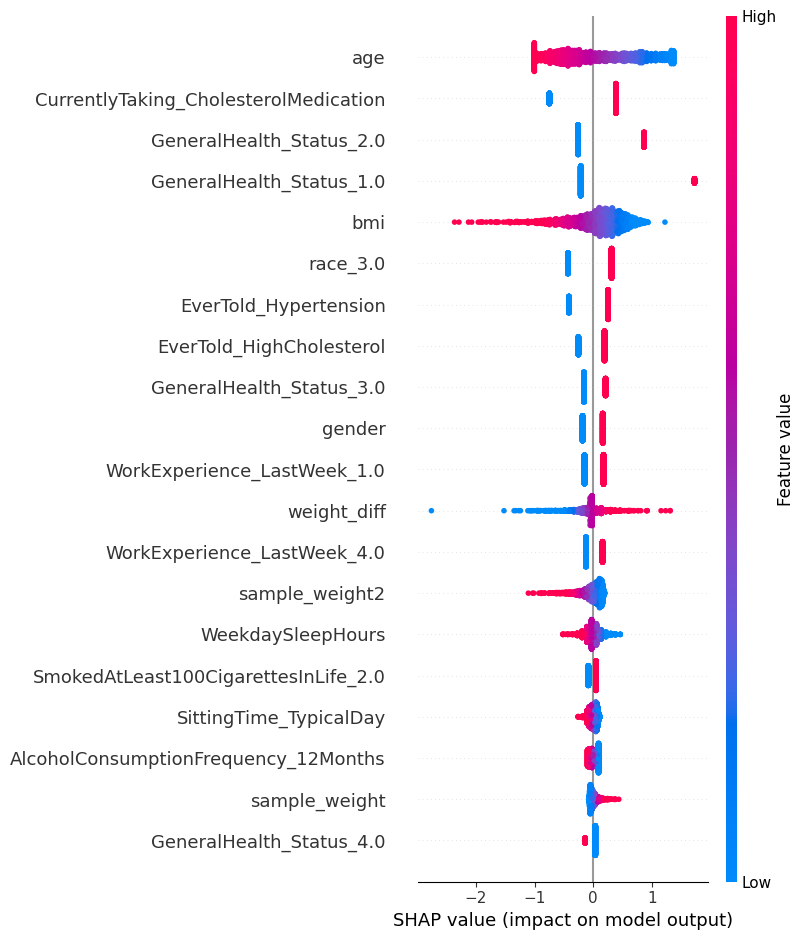

In [ ]:
X = X.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=500, class_weight='balanced')
model.fit(X_train, y_train)

explainer = shap.LinearExplainer(model, X_train)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [46]:
shap.initjs()

In [47]:
# Select a random instance from the test set
instance = X_test.iloc[[5]]

# Create a SHAP force plot for the selected instance
shap.force_plot(explainer.expected_value, shap_values[5], instance)
